In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

torch.manual_seed(42)

Using device: cuda


In [ ]:
import os

DATA_ROOT = './cifar10'

CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])


def load_cifar10(root, transform_train, transform_test):
    """Load CIFAR-10 from whatever local format is already on disk -- never downloads."""

    official_dir = os.path.join(root, 'cifar-10-batches-py')
    if os.path.isdir(official_dir):
        train_ds = torchvision.datasets.CIFAR10(
            root=root, train=True, download=False, transform=transform_train
        )
        test_ds = torchvision.datasets.CIFAR10(
            root=root, train=False, download=False, transform=transform_test
        )
        print('Loaded CIFAR-10 from the official torchvision batch format.')
        return train_ds, test_ds

    train_dir = os.path.join(root, 'train')
    test_dir = os.path.join(root, 'test')
    if os.path.isdir(train_dir) and os.path.isdir(test_dir):
        train_ds = torchvision.datasets.ImageFolder(train_dir, transform=transform_train)
        test_ds = torchvision.datasets.ImageFolder(test_dir, transform=transform_test)
        print('Loaded CIFAR-10 from train/ and test/ folders (one subfolder per class).')
        return train_ds, test_ds

    raise RuntimeError(
        f"Couldn't find CIFAR-10 under '{root}'. Expected either a 'cifar-10-batches-py' "
        f"folder (torchvision's official format) or 'train/' and 'test/' subfolders "
        f"(one subfolder per class) inside '{root}'."
    )


train_dataset, test_dataset = load_cifar10(DATA_ROOT, transform_train, transform_test)

BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=256, shuffle=False,
    num_workers=2, pin_memory=True
)

print(f'Train samples: {len(train_dataset)}')
print(f'Test samples:  {len(test_dataset)}')


Loaded CIFAR-10 from train/ and test/ folders (one subfolder per class).
Train samples: 50000
Test samples:  10000


In [ ]:
class BasicBlock(nn.Module):
    """Two 3x3 convs + a skip connection. The basic building block of ResNet-18/34."""
    expansion = 1  

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                                stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                                stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels * self.expansion:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels * self.expansion, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * self.expansion)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x) 
        out = F.relu(out)
        return out

class ResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)

     
        self.layer1 = self._make_layer(64,  num_blocks=2, stride=1) 
        self.layer2 = self._make_layer(128, num_blocks=2, stride=2) 
        self.layer3 = self._make_layer(256, num_blocks=2, stride=2)  
        self.layer4 = self._make_layer(512, num_blocks=2, stride=2) 

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))  
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, out_channels, num_blocks, stride):
      
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(BasicBlock(self.in_channels, out_channels, s))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)
        return out

In [ ]:
model = ResNet18(num_classes=10).to(device)

dummy_input = torch.randn(4, 3, 32, 32).to(device)
dummy_output = model(dummy_input)
print(f'Output shape: {dummy_output.shape}') 

num_params = sum(p.numel() for p in model.parameters())
print(f'Total trainable parameters: {num_params:,}') 

Output shape: torch.Size([4, 10])
Total trainable parameters: 11,173,962


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4
)

EPOCHS = 20
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    return running_loss / total, 100.0 * correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, targets)

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    return running_loss / total, 100.0 * correct / total

In [ ]:
train_losses = []
test_losses = []
test_accuracies = []

best_acc = 0.0

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    scheduler.step()

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), 'resnet18_cifar10_best.pth')

    current_lr = scheduler.get_last_lr()[0]
    print(f'Epoch [{epoch+1:3d}/{EPOCHS}] | '
          f'Train Loss: {train_loss:.4f}  Train Acc: {train_acc:6.2f}% | '
          f'Test Loss: {test_loss:.4f}  Test Acc: {test_acc:6.2f}% | '
          f'LR: {current_lr:.5f}')

print(f'\nBest test accuracy: {best_acc:.2f}%')

Epoch [  1/20] | Train Loss: 1.8182  Train Acc:  33.99% | Test Loss: 1.8129  Test Acc:  39.87% | LR: 0.09938
Epoch [  2/20] | Train Loss: 1.3531  Train Acc:  50.37% | Test Loss: 1.2861  Test Acc:  53.68% | LR: 0.09755
Epoch [  3/20] | Train Loss: 1.0733  Train Acc:  61.39% | Test Loss: 1.0112  Test Acc:  63.60% | LR: 0.09455
Epoch [  4/20] | Train Loss: 0.9005  Train Acc:  68.24% | Test Loss: 1.1110  Test Acc:  62.01% | LR: 0.09045
Epoch [  5/20] | Train Loss: 0.7634  Train Acc:  73.23% | Test Loss: 0.8136  Test Acc:  72.50% | LR: 0.08536
Epoch [  6/20] | Train Loss: 0.6501  Train Acc:  77.35% | Test Loss: 0.6887  Test Acc:  76.56% | LR: 0.07939
Epoch [  7/20] | Train Loss: 0.5743  Train Acc:  80.20% | Test Loss: 0.7048  Test Acc:  76.90% | LR: 0.07270
Epoch [  8/20] | Train Loss: 0.5260  Train Acc:  81.74% | Test Loss: 0.5251  Test Acc:  82.11% | LR: 0.06545
Epoch [  9/20] | Train Loss: 0.4719  Train Acc:  83.62% | Test Loss: 0.5777  Test Acc:  80.39% | LR: 0.05782
Epoch [ 10/20] | Tr

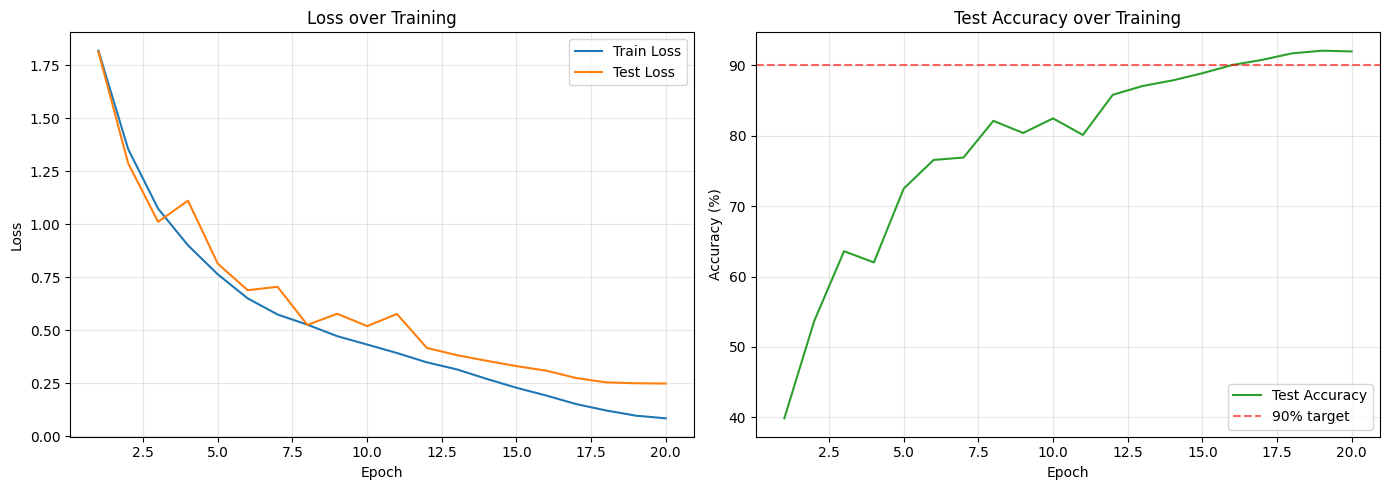

In [ ]:
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, train_losses, label='Train Loss', color='tab:blue')
axes[0].plot(epochs_range, test_losses, label='Test Loss', color='tab:orange')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss over Training')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, test_accuracies, label='Test Accuracy', color='tab:green')
axes[1].axhline(y=90, color='red', linestyle='--', alpha=0.6, label='90% target')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Test Accuracy over Training')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()